<a href="https://colab.research.google.com/github/KyleFranzR/CPE-313/blob/main/Rodriguez_Hands-on-Activity_7.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting the data and preprocessing

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from collections import Counter
import torch.nn.functional as F
from itertools import cycle

cudnn.benchmark = True
plt.ion()   # interactive mode

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Moving the dataset for faster access

import os
import zipfile

zip_path = '/content/drive/MyDrive/FastAI_ImageNet_v2/archive.zip'
local_path = '/content/local_data'

if not os.path.exists(local_path):
    os.makedirs(local_path)
    print("Copying zip to local disk...")
    !cp "{zip_path}" /content/dataset.zip

    print("Unzipping...")
    with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
        zip_ref.extractall(local_path)

    !rm /content/dataset.zip
    print("Finished")

Copying zip to local disk...
Unzipping...
Finished


In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation

# This will change image size to 128x128
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(128),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(144),
        transforms.CenterCrop(128),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/local_data/FastAI_ImageNet_v2'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],
                                              batch_size=64,
                                              shuffle=True,
                                              num_workers=4,
                                              pin_memory=True,
                                              persistent_workers=True)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Check the number of datapoints per classes

train_set = image_datasets['train']

print(f"Number of data per classes in training set:\n")
print("-" * 30)
for idx, count in Counter(train_set.targets).items():
    class_label = train_set.classes[idx]
    print(f"{class_label:15}: {count} images")
print("-" * 30)
print(f"Total classes found: {len(train_set.classes)}")

Number of data per classes in training set:

------------------------------
cassette_player: 993 images
chain_saw      : 858 images
church         : 941 images
english_springer: 955 images
french_horn    : 956 images
garbage_truck  : 961 images
gas_pump       : 931 images
golf_ball      : 951 images
parachute      : 960 images
tench          : 963 images
------------------------------
Total classes found: 10


# Preparing some pipeline for model training and evaluation

## For the training

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # dictionary to store scores for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Store metrics in history
                history[f'{phase}_loss'].append(epoch_loss)
                history[f'{phase}_acc'].append(epoch_acc.item())

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, history

## For the prediction of the model. Used for matrix and classification report

In [ ]:
def predictions(model, dataloader):
    model.eval()
    all_pred = []
    all_label = []

    with torch.no_grad():
        for input, label in dataloader:
            input = input.to(device)
            output = model(input)
            _, pred = torch.max(output, 1)
            all_pred.extend(pred.cpu().numpy())
            all_label.extend(label.cpu().numpy())

    return np.array(all_label), np.array(all_pred)

## For the predicted probabilities. Used for ROC curve.

In [ ]:
def y_probs(model, dataloader):
    model.eval()
    all_prob = []
    all_label = []

    with torch.no_grad():
        for input, label in dataloader:
            input = input.to(device)
            output = model(input)
            prob = F.softmax(output, dim=1)
            all_prob.extend(prob.cpu().numpy())
            all_label.extend(label.cpu().numpy())

    return np.array(all_label), np.array(all_prob)

# VGG-16 model from scratch

## Creating the model

Following this architecture from GeeksForGeeks:
> https://www.geeksforgeeks.org/computer-vision/vgg-16-cnn-model/

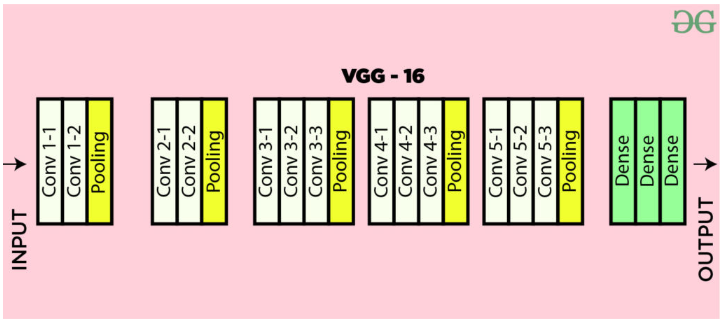

In [ ]:
class VGG16_model(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16_model, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 2048), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(2048, 2048), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(2048, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Training the model

In [ ]:
model = VGG16_model().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
epochs = 30

model, hist = train_model(model, criterion, optimizer, exp_lr_scheduler, epochs)

Epoch 0/29
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 2.4362 Acc: 0.1500
val Loss: 2.1334 Acc: 0.1987

Epoch 1/29
----------
train Loss: 2.1483 Acc: 0.2082
val Loss: 2.0937 Acc: 0.2290

Epoch 2/29
----------
train Loss: 2.1093 Acc: 0.2337
val Loss: 2.0198 Acc: 0.2512

Epoch 3/29
----------
train Loss: 2.0746 Acc: 0.2352
val Loss: 1.9775 Acc: 0.3019

Epoch 4/29
----------
train Loss: 2.0399 Acc: 0.2573
val Loss: 1.9255 Acc: 0.3146

Epoch 5/29
----------
train Loss: 1.9946 Acc: 0.2886
val Loss: 2.0601 Acc: 0.2237

Epoch 6/29
----------
train Loss: 1.9506 Acc: 0.3006
val Loss: 1.8357 Acc: 0.3376

Epoch 7/29
----------
train Loss: 1.8929 Acc: 0.3177
val Loss: 1.7792 Acc: 0.3855

Epoch 8/29
----------
train Loss: 1.8619 Acc: 0.3334
val Loss: 1.7569 Acc: 0.3883

Epoch 9/29
----------
train Loss: 1.8224 Acc: 0.3481
val Loss: 1.7286 Acc: 0.3901

Epoch 10/29
----------
train Loss: 1.7890 Acc: 0.3624
val Loss: 1.6387 Acc: 0.4260

Epoch 11/29
----------
train Loss: 1.7242 Acc: 0.3893
val Loss: 1.5946 Acc: 0.4576

Epoch 12/29
----------
t

> I managed to fix the slow training time by changing the referenced location of the dataset from drive to "local". Then, I removed the random horizontal flips in the data normalization part. I also made the batch size to 64, then turned on the pin_memory and persistent_workers parameter of the dataloaders.

## Evaluation and intepretation

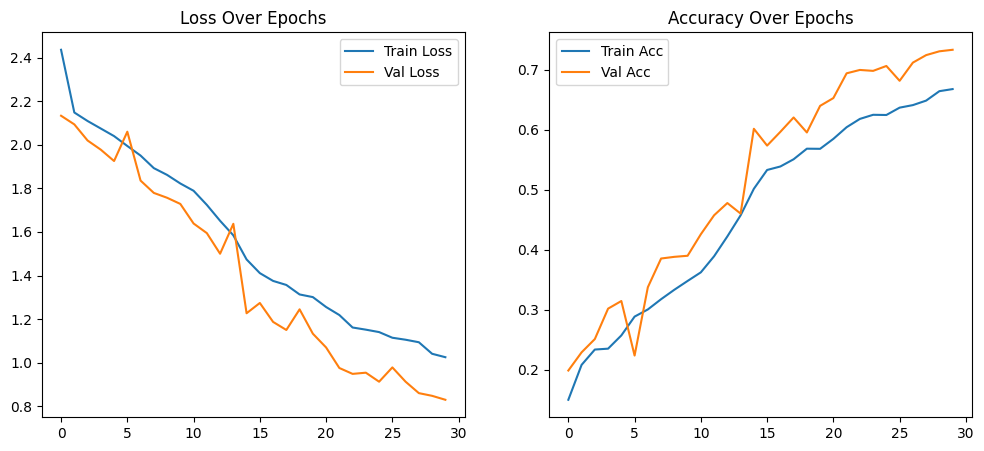

In [ ]:
# Plot the accuracy for both Training and Validation.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['train_acc'], label='Train Acc')
plt.plot(hist['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

Classification Report:

                  precision    recall  f1-score   support

 cassette_player       0.78      0.67      0.72       357
       chain_saw       0.48      0.45      0.46       386
          church       0.70      0.84      0.76       409
english_springer       0.82      0.83      0.82       395
     french_horn       0.82      0.72      0.77       394
   garbage_truck       0.71      0.83      0.77       389
        gas_pump       0.78      0.63      0.70       419
       golf_ball       0.63      0.75      0.69       399
       parachute       0.80      0.78      0.79       390
           tench       0.86      0.83      0.84       387

        accuracy                           0.73      3925
       macro avg       0.74      0.73      0.73      3925
    weighted avg       0.74      0.73      0.73      3925



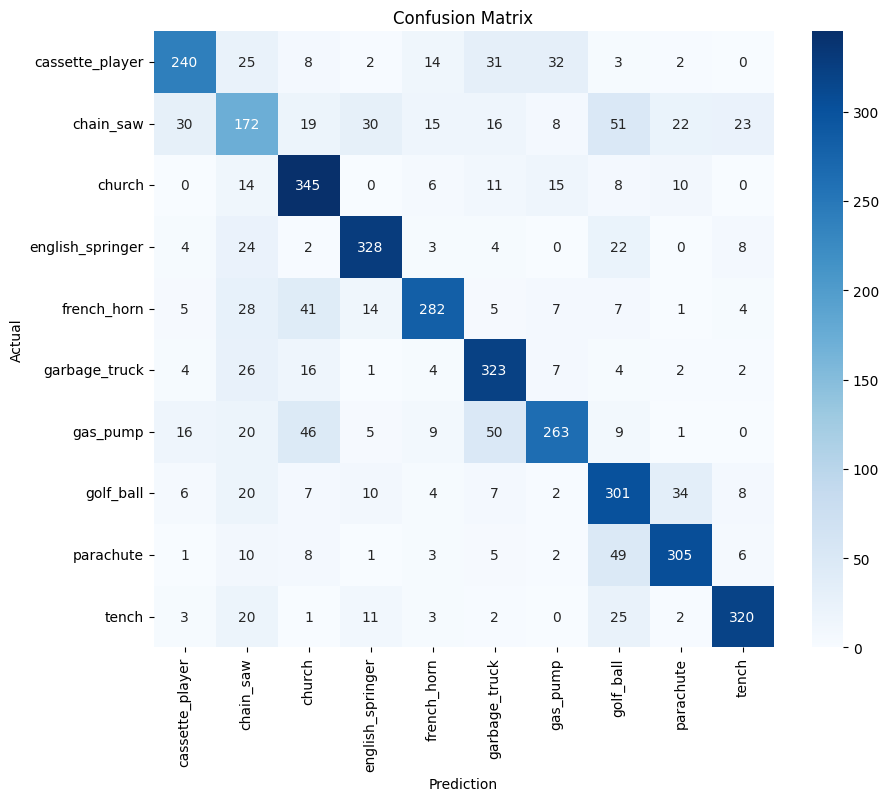

In [ ]:
# Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

y_true, y_pred = predictions(model, dataloaders['val'])

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

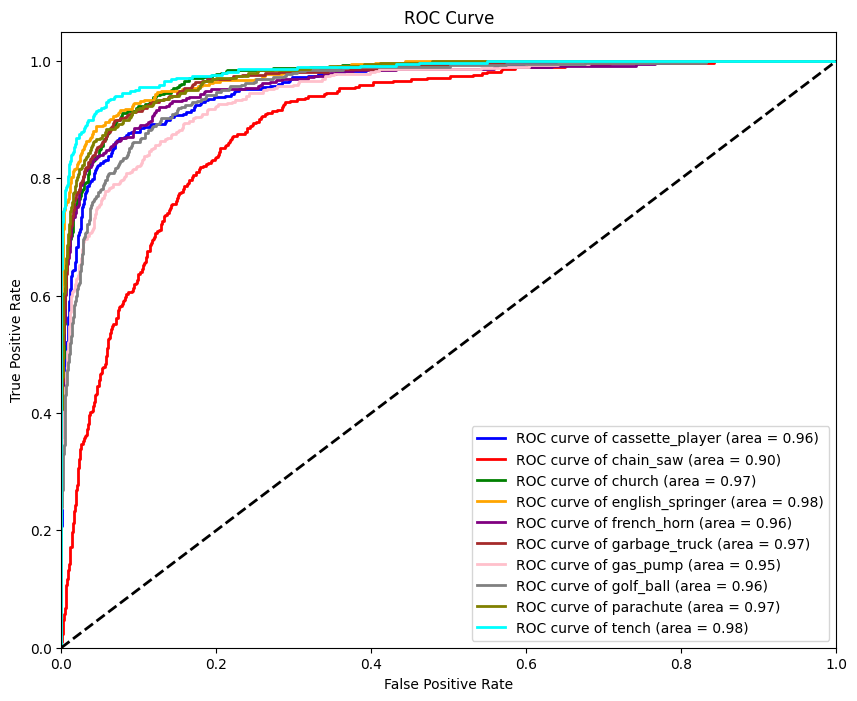

In [ ]:
# Plot the ROC AUC score result of the model

y_test, y_score = y_probs(model, dataloaders['val'])

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=[i for i in range(n_classes)])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

> ***After 30 epochs, the model managed to reach 0.73 accuracy. Based on the classification report and the confusion matrix, we can see that the model is having a hard time predicting the "chain_saw" class. The rest of the classes seemed to be near the 0.7 accuracy. Based on the ROC curve, the model has good performance, with all of the classes having a probability of above 0.9. Keep in mind that the parameters used in the architecture and in the training was by far the best value to produce the best accuracy compared to the previous tests that was made.  Based on the plotted accuracy and loss, we can see that the learning curve of the model is straight up increasing. With this, we can theorize that to increase the accuracy of the model, we have to increase the number of epochs. However, increasing the epochs would take up too much time, considering that each epoch would take around 1 minute each.***

# Pre-trained VGG-16 model

## Importing the model

In [ ]:
pre_model = models.vgg16(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 163MB/s]


In [ ]:
# adjust the final layers to match the dataset. Must have pre-trained weights.

for param in pre_model.parameters():
    param.requires_grad = False

pre_model.avgpool = nn.Identity()
pre_model.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 2048), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(2048, 2048), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(2048, 10),
        )

pre_model = pre_model.to(device)

## Training the model

In [ ]:
# Fine tune on the given dataset, plot the same metrics in #3 and #4.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pre_model.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
epochs = 30

In [ ]:
pre_model, hist = train_model(pre_model, criterion, optimizer, exp_lr_scheduler, epochs)

Epoch 0/29
----------
train Loss: 0.4785 Acc: 0.8606
val Loss: 0.1834 Acc: 0.9468

Epoch 1/29
----------
train Loss: 0.3394 Acc: 0.9047
val Loss: 0.1834 Acc: 0.9475

Epoch 2/29
----------
train Loss: 0.3018 Acc: 0.9147
val Loss: 0.1749 Acc: 0.9478

Epoch 3/29
----------
train Loss: 0.3197 Acc: 0.9102
val Loss: 0.1660 Acc: 0.9544

Epoch 4/29
----------
train Loss: 0.3049 Acc: 0.9175
val Loss: 0.1406 Acc: 0.9628

Epoch 5/29
----------
train Loss: 0.3185 Acc: 0.9158
val Loss: 0.1400 Acc: 0.9651

Epoch 6/29
----------
train Loss: 0.3039 Acc: 0.9165
val Loss: 0.1447 Acc: 0.9587

Epoch 7/29
----------
train Loss: 0.2431 Acc: 0.9353
val Loss: 0.1213 Acc: 0.9661

Epoch 8/29
----------
train Loss: 0.2070 Acc: 0.9398
val Loss: 0.1217 Acc: 0.9654

Epoch 9/29
----------
train Loss: 0.2079 Acc: 0.9406
val Loss: 0.1178 Acc: 0.9697

Epoch 10/29
----------
train Loss: 0.2047 Acc: 0.9432
val Loss: 0.1127 Acc: 0.9682

Epoch 11/29
----------
train Loss: 0.1984 Acc: 0.9421
val Loss: 0.1101 Acc: 0.9679

Ep

## Evaluation and interpretation

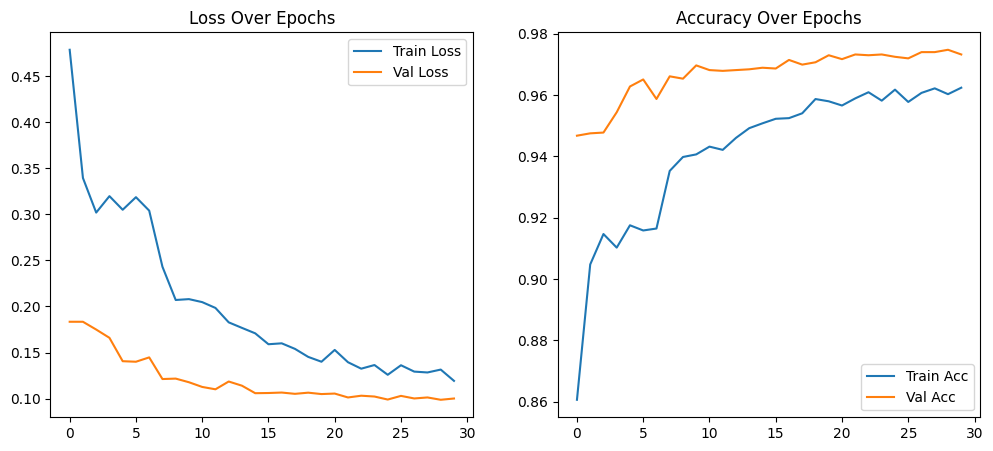

In [ ]:
# Plot the accuracy for both Training and Validation.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['train_acc'], label='Train Acc')
plt.plot(hist['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

Classification Report:

                  precision    recall  f1-score   support

 cassette_player       0.97      0.97      0.97       357
       chain_saw       0.95      0.95      0.95       386
          church       0.97      0.99      0.98       409
english_springer       1.00      0.99      0.99       395
     french_horn       0.96      0.98      0.97       394
   garbage_truck       0.97      0.98      0.98       389
        gas_pump       0.98      0.95      0.96       419
       golf_ball       0.98      0.97      0.98       399
       parachute       0.98      0.98      0.98       390
           tench       0.98      0.98      0.98       387

        accuracy                           0.97      3925
       macro avg       0.97      0.97      0.97      3925
    weighted avg       0.97      0.97      0.97      3925



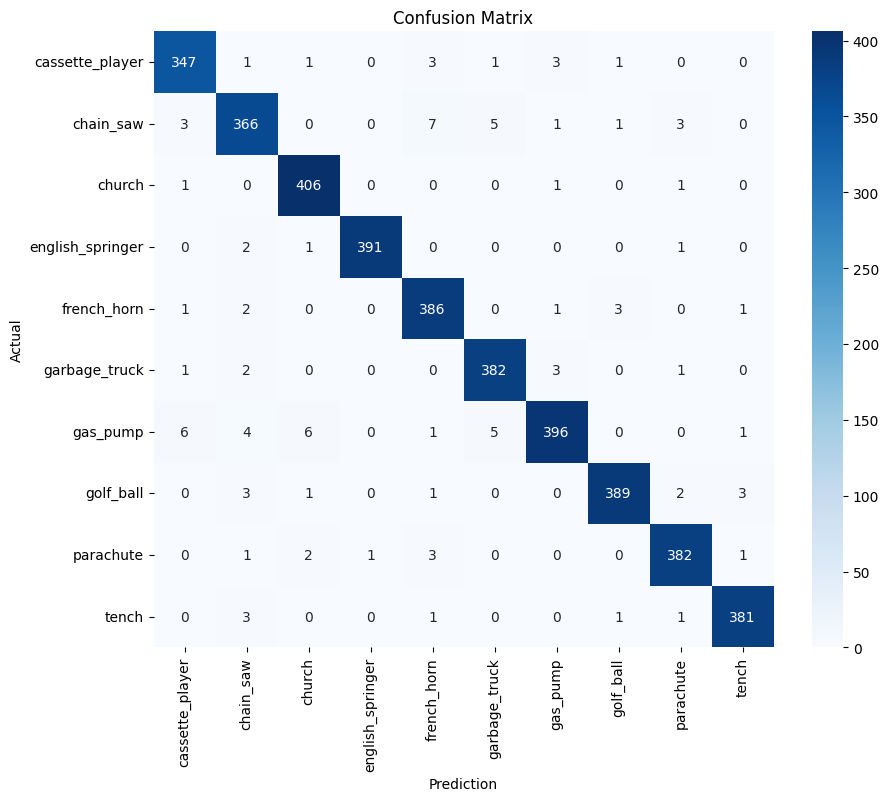

In [ ]:
# Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

y_true, y_pred = predictions(pre_model, dataloaders['val'])

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

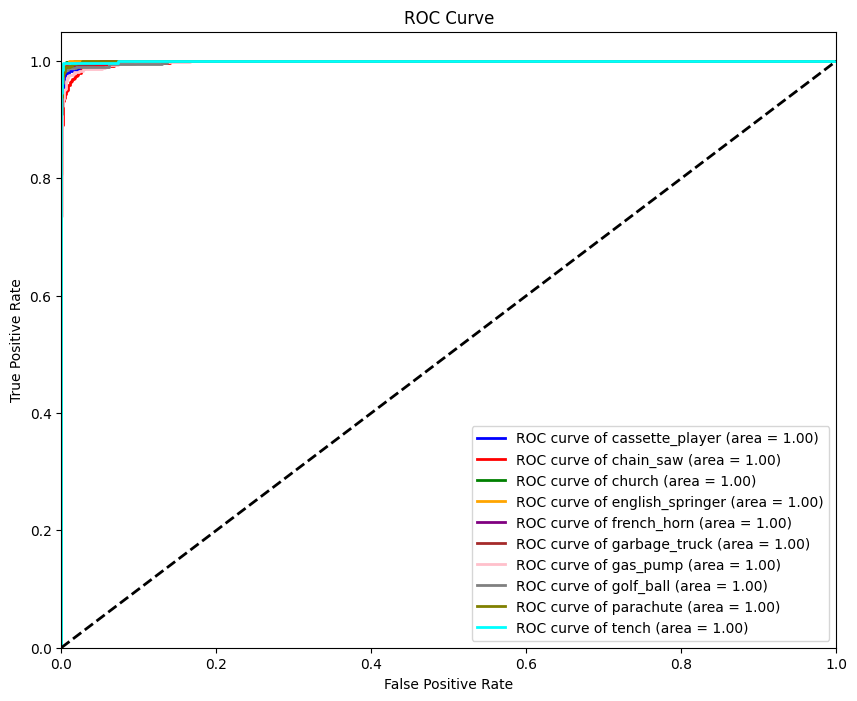

In [ ]:
# Plot the ROC AUC score result of the model

y_test, y_score = y_probs(pre_model, dataloaders['val'])

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=[i for i in range(n_classes)])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

> ***Based on the performance that was shown, the model started the accuracy from 0.8 and reached above 0.95 at the 3rd epoch. Considering that this model was pre-trained, it is no surprise that its performance would immediately be acceptable. Comparing it to the previous model that was made from scratch, we think that the performance of the model that was made from the scratch can match the performance of this pre-trained model if given enough time to train more epochs.***

# MobileNetV2 from scratch

## Creating the model

In [ ]:
class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))

        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        return self.conv(x)

In [ ]:
class MobileNetV2_model(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNetV2_model, self).__init__()

        self.cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        input_channel = 32
        layers = [nn.Sequential(
            nn.Conv2d(3, input_channel, 3, 2, 1, bias=False),
            nn.BatchNorm2d(input_channel),
            nn.ReLU6(inplace=True)
        )]

        for t, c, n, s in self.cfgs:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidual(input_channel, c, stride, expand_ratio=t))
                input_channel = c

        layers.append(nn.Sequential(
            nn.Conv2d(input_channel, 1280, 1, 1, 0, bias=False),
            nn.BatchNorm2d(1280),
            nn.ReLU6(inplace=True)
        ))

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])
        x = self.classifier(x)
        return x

## Training the model

In [ ]:
model = MobileNetV2_model().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
epochs = 30

model, hist = train_model(model, criterion, optimizer, exp_lr_scheduler, epochs)

Epoch 0/29
----------
train Loss: 2.0307 Acc: 0.2771
val Loss: 1.8737 Acc: 0.3631

Epoch 1/29
----------
train Loss: 1.7379 Acc: 0.4070
val Loss: 1.5190 Acc: 0.4882

Epoch 2/29
----------
train Loss: 1.5497 Acc: 0.4730
val Loss: 1.3702 Acc: 0.5521

Epoch 3/29
----------
train Loss: 1.4398 Acc: 0.5236
val Loss: 1.2537 Acc: 0.5857

Epoch 4/29
----------
train Loss: 1.3610 Acc: 0.5499
val Loss: 1.1605 Acc: 0.6112

Epoch 5/29
----------
train Loss: 1.2751 Acc: 0.5832
val Loss: 1.1894 Acc: 0.6252

Epoch 6/29
----------
train Loss: 1.2072 Acc: 0.6044
val Loss: 1.2151 Acc: 0.6138

Epoch 7/29
----------
train Loss: 1.0717 Acc: 0.6465
val Loss: 0.8439 Acc: 0.7248

Epoch 8/29
----------
train Loss: 1.0167 Acc: 0.6667
val Loss: 0.8183 Acc: 0.7343

Epoch 9/29
----------
train Loss: 0.9872 Acc: 0.6745
val Loss: 0.8055 Acc: 0.7368

Epoch 10/29
----------
train Loss: 0.9682 Acc: 0.6855
val Loss: 0.7864 Acc: 0.7414

Epoch 11/29
----------
train Loss: 0.9536 Acc: 0.6857
val Loss: 0.7791 Acc: 0.7465

Ep

## Evaluation and interpretation

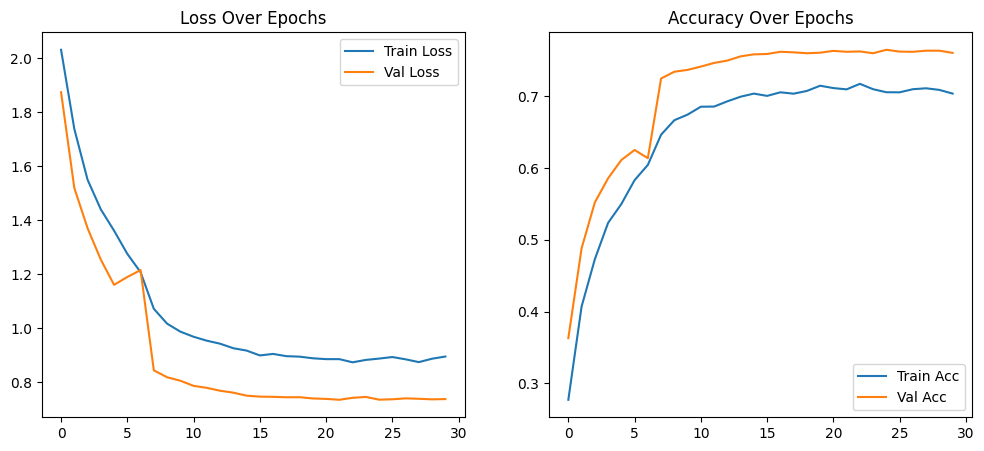

In [ ]:
# Plot the accuracy for both Training and Validation.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['train_acc'], label='Train Acc')
plt.plot(hist['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

Classification Report:

                  precision    recall  f1-score   support

 cassette_player       0.74      0.78      0.76       357
       chain_saw       0.58      0.58      0.58       386
          church       0.78      0.81      0.80       409
english_springer       0.81      0.83      0.82       395
     french_horn       0.75      0.77      0.76       394
   garbage_truck       0.76      0.83      0.79       389
        gas_pump       0.77      0.69      0.73       419
       golf_ball       0.79      0.72      0.76       399
       parachute       0.87      0.81      0.84       390
           tench       0.80      0.83      0.82       387

        accuracy                           0.76      3925
       macro avg       0.77      0.77      0.76      3925
    weighted avg       0.77      0.76      0.76      3925



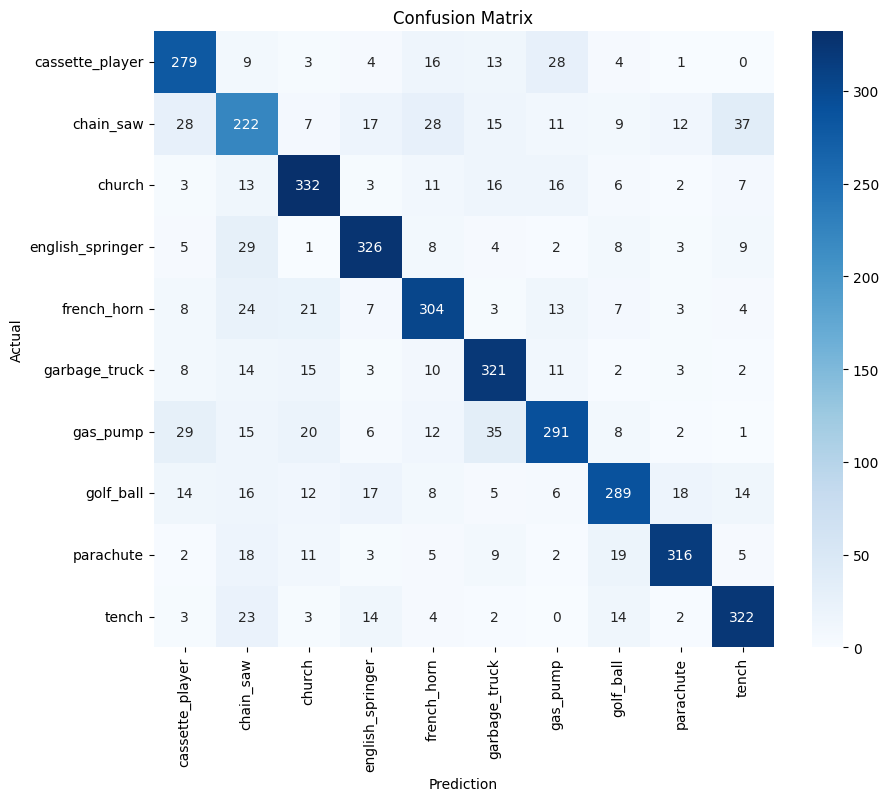

In [ ]:
# Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

y_true, y_pred = predictions(model, dataloaders['val'])

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

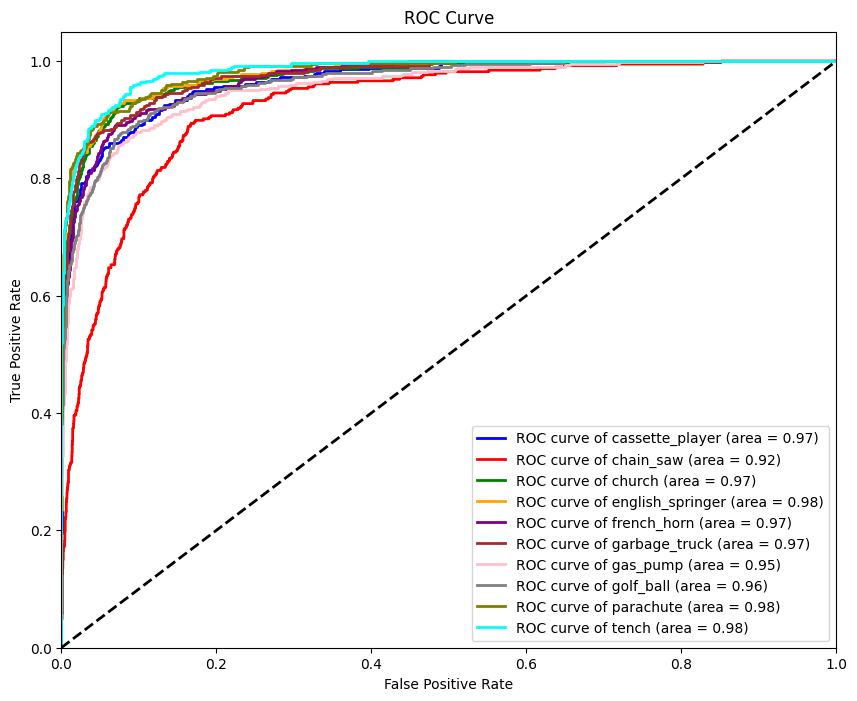

In [ ]:
# Plot the ROC AUC score result of the model

y_test, y_score = y_probs(model, dataloaders['val'])

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=[i for i in range(n_classes)])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

> ***After 30 epochs, the model achieved an accuracy of 0.76. The same with VGG-16 model, it strunggles with predicting chain_saw. Based on the loss and accuracy plot, the model seems to get stuck after getting to 0.7, indicating that it needs more finetuning in either modifying the architecture or the training parameters. Given the shown ROC curve, the model seems to be learning appropriately, just slightly underfitted. Overall, the result was about the same as the previous VGG-16 model that was made in the procedures.***

# Pre-trained MobileNetV2

## Importing the model

In [ ]:
pre_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 204MB/s]


In [ ]:
for param in pre_model.parameters():
    param.requires_grad = False

pre_model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 10),
        )

pre_model = pre_model.to(device)

## Training the model

In [ ]:
# Have to adjust dataloader num_workers, otherwise crash

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],
                                              batch_size=64,
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True,
                                              persistent_workers=True)
              for x in ['train', 'val']}

In [ ]:
# Fine tune on the given dataset, plot the same metrics in #3 and #4.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pre_model.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
epochs = 30

In [ ]:
pre_model, hist = train_model(pre_model, criterion, optimizer, exp_lr_scheduler, epochs)

Epoch 0/29
----------
train Loss: 0.5186 Acc: 0.8671
val Loss: 0.1757 Acc: 0.9493

Epoch 1/29
----------
train Loss: 0.2829 Acc: 0.9137
val Loss: 0.1430 Acc: 0.9600

Epoch 2/29
----------
train Loss: 0.2522 Acc: 0.9211
val Loss: 0.1413 Acc: 0.9549

Epoch 3/29
----------
train Loss: 0.2488 Acc: 0.9229
val Loss: 0.1351 Acc: 0.9539

Epoch 4/29
----------
train Loss: 0.2432 Acc: 0.9198
val Loss: 0.1346 Acc: 0.9562

Epoch 5/29
----------
train Loss: 0.2201 Acc: 0.9316
val Loss: 0.1283 Acc: 0.9585

Epoch 6/29
----------
train Loss: 0.2306 Acc: 0.9262
val Loss: 0.1279 Acc: 0.9572

Epoch 7/29
----------
train Loss: 0.2185 Acc: 0.9309
val Loss: 0.1253 Acc: 0.9595

Epoch 8/29
----------
train Loss: 0.2209 Acc: 0.9264
val Loss: 0.1245 Acc: 0.9590

Epoch 9/29
----------
train Loss: 0.2051 Acc: 0.9338
val Loss: 0.1241 Acc: 0.9597

Epoch 10/29
----------
train Loss: 0.2084 Acc: 0.9348
val Loss: 0.1282 Acc: 0.9575

Epoch 11/29
----------
train Loss: 0.2157 Acc: 0.9334
val Loss: 0.1220 Acc: 0.9597

Ep

## Evaluation and interpretation

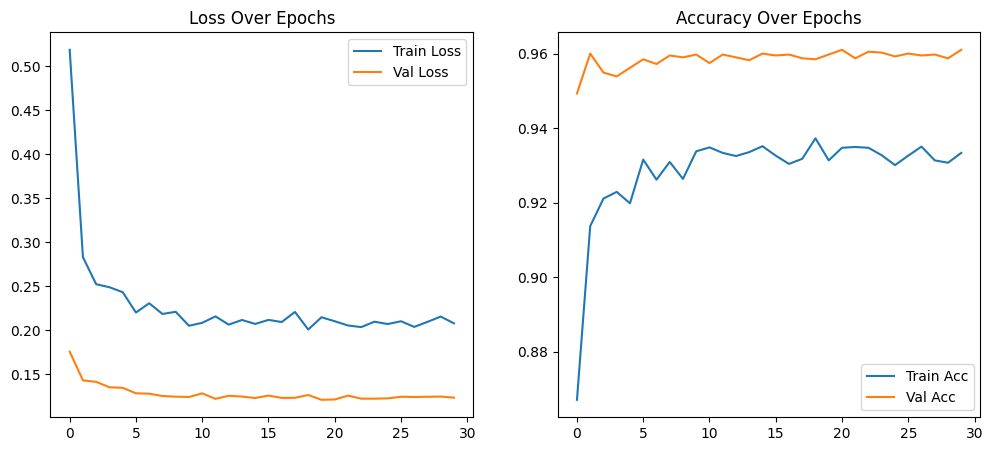

In [48]:
# Plot the accuracy for both Training and Validation.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['train_acc'], label='Train Acc')
plt.plot(hist['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

Classification Report:

                  precision    recall  f1-score   support

 cassette_player       0.95      0.94      0.94       357
       chain_saw       0.93      0.92      0.92       386
          church       0.97      0.98      0.98       409
english_springer       0.99      0.98      0.98       395
     french_horn       0.95      0.96      0.96       394
   garbage_truck       0.94      0.96      0.95       389
        gas_pump       0.95      0.93      0.94       419
       golf_ball       0.98      0.97      0.98       399
       parachute       0.97      0.97      0.97       390
           tench       0.98      0.98      0.98       387

        accuracy                           0.96      3925
       macro avg       0.96      0.96      0.96      3925
    weighted avg       0.96      0.96      0.96      3925



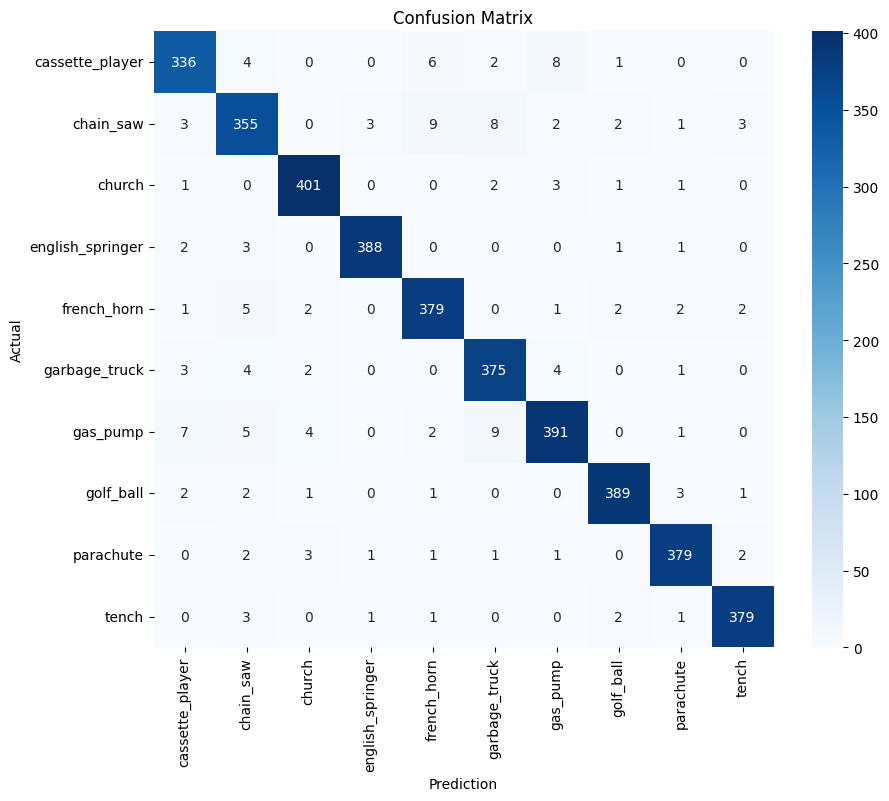

In [49]:
# Include a confusion matrix, and a classification report (Precision, Recall , F1 score, Sensitivity)

y_true, y_pred = predictions(pre_model, dataloaders['val'])

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

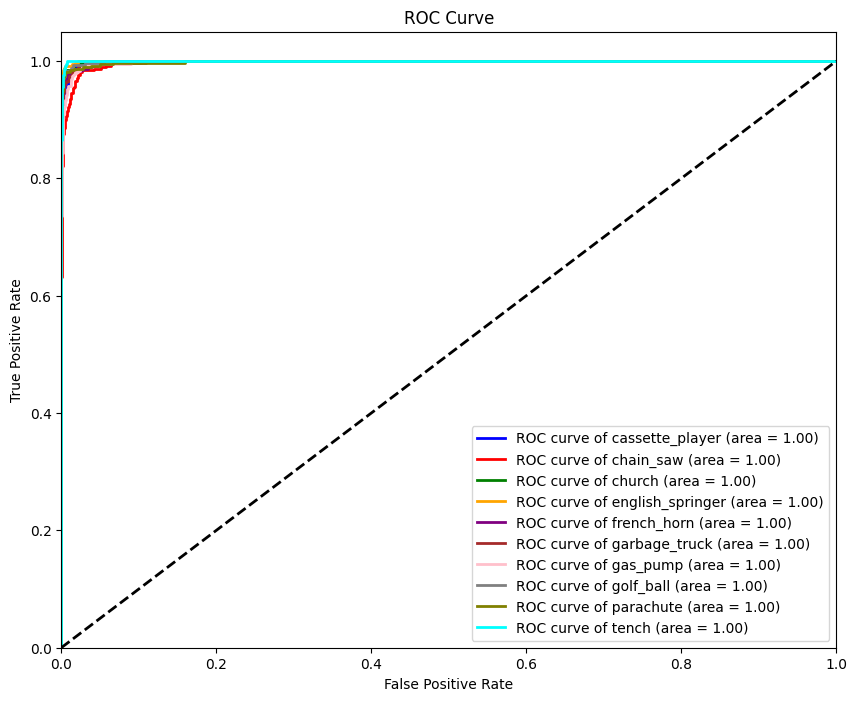

In [50]:
# Plot the ROC AUC score result of the model

y_test, y_score = y_probs(pre_model, dataloaders['val'])

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=[i for i in range(n_classes)])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

> ***Almost immediately, the model reached an accuracy of 0.96 after 2 epochs. Compared to the previous model that was made from scratch, it seems that previous model can't match the performance of this new model.***

# Conclusion

> ***In this activity, we applied 2 ways to create and train 2 image classification models. The two ways are building the model from the scratch which doesn't have weights from the start, and the other way was transfer learning where we are just modifying the weights of a model that already weights because they are already trained. For this activity, we used pytorch library instead of tensorflow. Based on what was done in the activity, for the procedure, we compared VGG-16 models. One was made from scratch and one was transfer learned. After comparison, the one that was made from scratch, although did not reach 0.95, could theoretically match the pre-trained one because the accuracy plot showed no skew and the rise in accuracy is consistent. Moving on to the supplementary part, we compared MobileNetV2 models. One was made from scratch and one was transfer learned. Creating this model was different from how the architecture of VGG-16 was made because it uses inverted residual block which is present in the library of pytorch. Additionally, we did not need to modify the whole model if we change the image size. After comparison, the one that was made from scratch can't match the pre-trained one because we probably did not finetune the architecure and the training parameters well. Overall, this activity is a great exercise that allows us to demonstrate how to make a model from "scratch" and how to transfer learn.***